In [17]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import math
%matplotlib inline

To visualize a dense neural network, we will draw a graph in code  

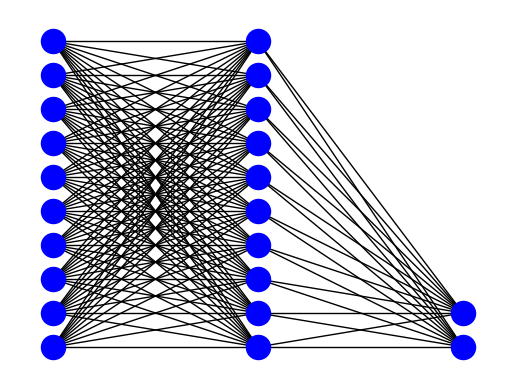

In [18]:
dense = nx.Graph()
inputs = {i: (0,i) for i in range(0,10)}
activations = {i+100: (1,i) for i in range(0,10)}
outputs = {i+1000: (2,i) for i in range(0,2)}
all = {**inputs, **activations, **outputs}

# and now -- fully connected
for input in inputs:
    for activation in activations:
        dense.add_edge(input, activation)
for activation in activations:
    for output in outputs:
        dense.add_edge(activation, output)
nx.draw_networkx_nodes(dense, all, nodelist=all.keys(), node_color='b')
nx.draw_networkx_edges(dense, all)
plt.axis('off')
pass

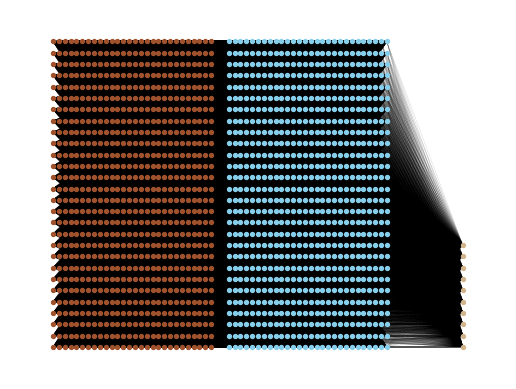

In [19]:
import itertools
mnist = nx.Graph()
pixels = {i: (x,y) for i,(x,y) in enumerate(itertools.product(range(0,28),range(0,28)))}
activations = {i+1000: (x+30,y) for i,(x,y) in enumerate(itertools.product(range(0,28),range(0,28)))}
digits = {i+2000: (70,i) for i in range(0,10)}
all = {**pixels,**activations,**digits}

for pixel in pixels:
    for activation in activations:
        mnist.add_edge(pixel,activation)

for activation in activations:
    for digit in digits:
        mnist.add_edge(activation,digit)

nx.draw_networkx_nodes(mnist,pixels,nodelist=pixels.keys(),node_color='sienna', node_size=8)
nx.draw_networkx_nodes(mnist,activations,nodelist=activations.keys(),node_color='skyblue', node_size=8)
nx.draw_networkx_nodes(mnist,digits,nodelist=digits.keys(),node_color='tan', node_size=8)
nx.draw_networkx_edges(mnist,all,width=0.1,alpha=0.5)
plt.axis('off')
pass

What makes a neural network able to learn interesting patterns is the concept of non-linearity. Very literally this means a function that does not generate a straight line.   
   
Very commonly 2 kinds of non-linearity are used -- relu and sigmoid. These non-linear activation functions will be used in layers of neural network.   

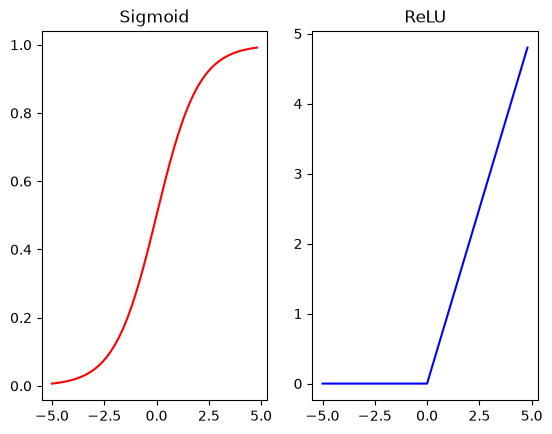

In [20]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def relu(x):
    return np.maximum(x,0)

x = np.arange(-5.,5.,0.2)
plt.subplot(121)
plt.title('Sigmoid')
plt.plot(x,sigmoid(x),'r-')
plt.subplot(122)
plt.title('ReLU')
plt.plot(x,relu(x),'b-')
pass

And on output, our output classes work best when we can think of them as probabilities that all add up to 1. This way we can tell the best matching prediction made by our neural network.

Softmax is an output activation function. It generates probabilities. Probabilities simulate confidence.

In [21]:
def softmax(x):
    return np.exp(x)/np.sum(np.exp(x),axis=0)

sample_outputs = [1,2,5]
softmax(sample_outputs)

array([0.01714783, 0.04661262, 0.93623955])

In [22]:
softmax(sample_outputs).sum()

np.float64(1.0)

we use `argmax()` to get the index where the probability is maximum.

Now, with these concepts in mind, let's actually build a dense neural network to learn and recognize handwritten digits. Starting with the training and testing data.

In [23]:
import keras
from keras.datasets import mnist
from keras.layers import Dense,Input,Dropout,Flatten
from keras.models import Model

In [24]:
(x_train,y_train),(x_test,y_test)= mnist.load_data()
x_train = x_train/np.max(x_train)
x_test = x_test/np.max(x_test)
y_train = keras.utils.to_categorical(y_train,num_classes=10)
y_test = keras.utils.to_categorical(y_test,num_classes=10)

In [25]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((60000, 28, 28), (60000, 10), (10000, 28, 28), (10000, 10))

Now, using the Keras functional API, stack together layers starting with the input, through dense and dropout learning layers, and then on to a final softmax output. 
    
Dropout is a device to help your network, not memorize the input. The larger the number of parameters in your model, the larger the chance your model memorize the input. Dropout is selective forgetting, turning off parts of the model randomly to avoid memorization.   

One thing to note here is Flatten. Because our images are 2 dimensional x,y pairs, and our output is one dimension -- a class 0-9, flatten is needed to reduce the dimension.

Over-fitting is memorization. It means machine learning models are memorizing the set of inputs.

In [26]:
input_layer = Input(shape=x_train[0].shape)
dense_1 = Dense(32,activation='relu')(input_layer)
dropout_1 = Dropout(0.1)(dense_1)
dense_2 = Dense(32,activation='relu')(dropout_1)
dropout_2 = Dropout(0.1)(dense_2)
flat = Flatten()(dropout_2)
output_layer = Dense(10,activation='softmax')(flat)
model = Model(inputs=[input_layer],outputs=[output_layer])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 28, 32)         │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 28, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         8,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,954 (42.79 KB)

 Trainable params: 10,954 (42.79 KB)

 Non-trainable params: 0 (0.00 B)

With the model assembled, we compile it, which prepares the model for execution with a solver. The solver is a mathematical search engine, it works through the possible values of our trainable parameters. This seems like a lot of work -- and it is -- but multiple different solver algorithms exist which prevent the solver from looking at every possible number.    

The trick is the *loss* which is feedback to the solver as to whether it is getting better or worse. Picking the right loss function to work with your network is important, but can be approached as a cookbook.    

The loss functions are a bit hard to relate to, so we also have a metric. Accuracy is straight forward, telling you the percentage of time your model predicted the right answer.          

In [27]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.fit(x_train,y_train,batch_size=64,epochs=8,verbose=1,validation_data=(x_test,y_test))
# batch size is number of images per execution loop. Generally it is limited by available memory.Small batch sizes 
# like 32,56 generally performs better.

Epoch 1/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8739 - loss: 0.4266 - val_accuracy: 0.9427 - val_loss: 0.1905
Epoch 2/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9431 - loss: 0.1935 - val_accuracy: 0.9577 - val_loss: 0.1440
Epoch 3/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9510 - loss: 0.1621 - val_accuracy: 0.9599 - val_loss: 0.1329
Epoch 4/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9565 - loss: 0.1458 - val_accuracy: 0.9633 - val_loss: 0.1224
Epoch 5/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9584 - loss: 0.1380 - val_accuracy: 0.9649 - val_loss: 0.1176
Epoch 6/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9614 - loss: 0.1286 - val_accuracy: 0.9642 - val_loss: 0.1115
Epoch 7/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9627 - loss: 0.1241 - val_accuracy: 0.9666 - val_loss: 0.1124
Epoch 8/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9629 - loss: 0.1210 - val_accu

loss is a mathematical function that tells the optimizer how well it's doing. An optimizer is a mathematical program that searches the available parameters in order to minimize the loss. metrics are output from your machine learning model that should be human readable so you can understand how your model is running.'adam' is default optimizer. 

Parameters are numbers found by the solver, instead by the model. Hyperparameters are numbers or settings we supply to create the model. Building a better model involves iteration and tuning these hyperparameters. Hyperparameters are machine learned parameters and there are 3 types of parameters: Trainable  parameters, Non-trainable parameters, hyperparameters. Trainable parameters are parameters that are learned by solvers. Non-trainable parameters are additional parameters in model that don't require training. Hyperparameters are parameters that are not learned by traditional solvers and they are outside of model, Example: number of layers, size of the layers, 0.1 in dropout layer is hyperparameter, 32 in dense layer is hyperparameter, choice of activation function say relu is a hyperparameter.  
     
Fortunately, we can also use another layer of machine learning -- Grid Search -- to work through a set of hyperparameters for us. Grid search uses cross validation, splitting the training data up into folds for training and testing of each hyperparameter combination. After all hyperparameter variants are trained, the original test data is used to validate the final model.     


##### Grid Search

optimization solves parameters with feedback from loss. Specifically, solver does not have to try every parameter value in order to work. It uses a mathematical relationship through partial derivatives in order to move around and that is called grid search. Grid search explores parameters with brute force. Grid search is radically less efficient than optimization then why we use it ? We use it when we learn parameters that can't be solved by an optimizer which is a common scenario in machine learning.  

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Dense
import time

In [29]:
def dense_model(units, dropout):
    model = Sequential()
    model.add(Input(shape=(28,28)))
    model.add(Dense(units, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(units,activation='relu'))
    model.add(Dropout(dropout))
    model.add(Flatten())
    model.add(Dense(10,activation='softmax'))
    # sparse_categorical_crossentropy so SciKeras can keep the 0-9 integer labels
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# SciKeras routes parameters of the model building function through the
# `model__` prefix, so 'units' becomes 'model__units', etc.
hyperparameters = {
    'epochs': [1],
    'batch_size': [64],
    'model__units': [32,64,128],
    'model__dropout': [0.1,0.2,0.4]
}
# SciKeras takes the builder as `model=` (not `build_fn=`), and every routed
# parameter must also have a default in the constructor.
model = KerasClassifier(model=dense_model, model__units=32, model__dropout=0.1, verbose=0)
start = time.perf_counter()
grid = GridSearchCV(estimator=model,param_grid=hyperparameters,cv=6,verbose=4)

# y_train is one-hot encoded above, so fit on 0-9 digit labels instead
grid_result = grid.fit(x_train,np.argmax(y_train,axis=1))
print("Best: %f using %s" %(grid_result.best_score_,grid_result.best_params_))

# The KerasClassifier comes back with the labels 0-9, so we use argmax
# to turn our one-hot encoding into 0-9 digit labels

y_true,y_pred = np.argmax(y_test,axis=1), grid.predict(x_test)
print()
print(classification_report(y_true,y_pred))
print()
print(time.perf_counter()-start)

Fitting 6 folds for each of 9 candidates, totalling 54 fits
[CV 1/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=32;, score=0.933 total time=   7.6s
[CV 2/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=32;, score=0.928 total time=   7.4s
[CV 3/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=32;, score=0.930 total time=   7.3s
[CV 4/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=32;, score=0.921 total time=   7.4s
[CV 5/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=32;, score=0.927 total time=   7.4s
[CV 6/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=32;, score=0.941 total time=   7.5s
[CV 1/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=64;, score=0.943 total time=   7.6s
[CV 2/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=64;, score=0.945 total time=   7.5s
[CV 3/6] END batch_size=64, epochs=1, model__dropout=0.1, model__units=64;, score=0.